In [1]:
!nvidia-smi

Sun Dec 28 15:14:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.29
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

In [3]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Mounted at /content/drive


In [4]:
def plot_results(Zj, Rj, algorithm):

    # Crear una figura con dos subplots verticales
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Agregar un título general
    fig.suptitle(f"Comparison of Riot Targets: Simulation {algorithm} vs Zj (real values SOSAFE)", fontsize=16, y=1.05)

    # Primer subplot para Zj
    x1 = np.arange(len(Zj))
    y1 = Zj
    ax1.plot(x1, y1)
    ax1.set_xlabel('Target Points')
    ax1.set_ylabel('Rioters')
    ax1.set_title('Line Plot of Zj')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Segundo subplot para Rj
    x2 = np.arange(len(Rj))
    y2 = Rj
    ax2.plot(x2, y2)
    ax2.set_xlabel('Target Points')
    ax2.set_ylabel('Rioters')
    ax2.set_title('Line Plot of Rj')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
def run_simulation(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau, Ptotal = 0.005, 0.75, 500.0
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = torch.sum(Sij_t.sum(dim=1), dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = Ptotal * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    scaler = MinMaxScaler()
    Rj_scaled = scaler.fit_transform(Rj_t.reshape(-1, 1)).flatten()

    # Preparar los datos
    x = np.arange(len(Rj_scaled))
    y = Rj_scaled

    # Detectar picos en los datos originales
    peaks, _ = find_peaks(y, prominence=0.1)

    if len(peaks) == 0:
        # If no peaks are found, return a flat line at the mean
        lowess_full_curve = np.full_like(x, np.mean(y))
    else:
        peaks = np.insert(peaks, 0, 0)
        peaks = np.append(peaks, len(y)-1)

        # Filtrar los valores de los picos
        x_peaks = x[peaks]
        y_peaks = y[peaks]

        # Lowess
        lowess = sm.nonparametric.lowess(y_peaks, x_peaks, frac=0.1)
        lowess_x = lowess[:, 0]
        lowess_y = lowess[:, 1]

        # El resultado de LOWESS solo tiene puntos en los picos. Para una comparación
        # justa, lo interpolamos para que tenga la misma longitud que los datos reales.
        lowess_full_curve = np.interp(x, lowess_x, lowess_y)

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return lowess_full_curve

In [7]:
# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")

# PSO parameters
beta_r = 0.1
gamma_r = 0.19482765
alpha_p = 0.97356374
gamma_p = 0.03415131

Rj_simulated = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

Starting loop ...
Total execution time:  3.7065978050231934


In [8]:
def calculate_errors_sklearn(predicted, real):

    predicted = predicted.flatten()
    real = real.flatten()

    mse = mean_squared_error(real, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(real, predicted)
    r2 = r2_score(real, predicted)

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "max_error": np.max(np.abs(real - predicted))
    }

    return metrics

def print_detailed_comparison_sklearn(predicted, real):
    metrics = calculate_errors_sklearn(predicted, real)

    print("Métricas de error:")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"Error máximo: {metrics['max_error']:.4f}")

In [9]:
scaler = MinMaxScaler()
Zj_scaled = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten()

In [10]:
print_detailed_comparison_sklearn(Rj_simulated, Zj_scaled)

Métricas de error:
RMSE: 0.0486
MAE: 0.0464
R² Score: 0.8677
Error máximo: 0.0988


In [11]:
print(np.linalg.norm(Rj_simulated - Zj_scaled))

1.0866691655863443


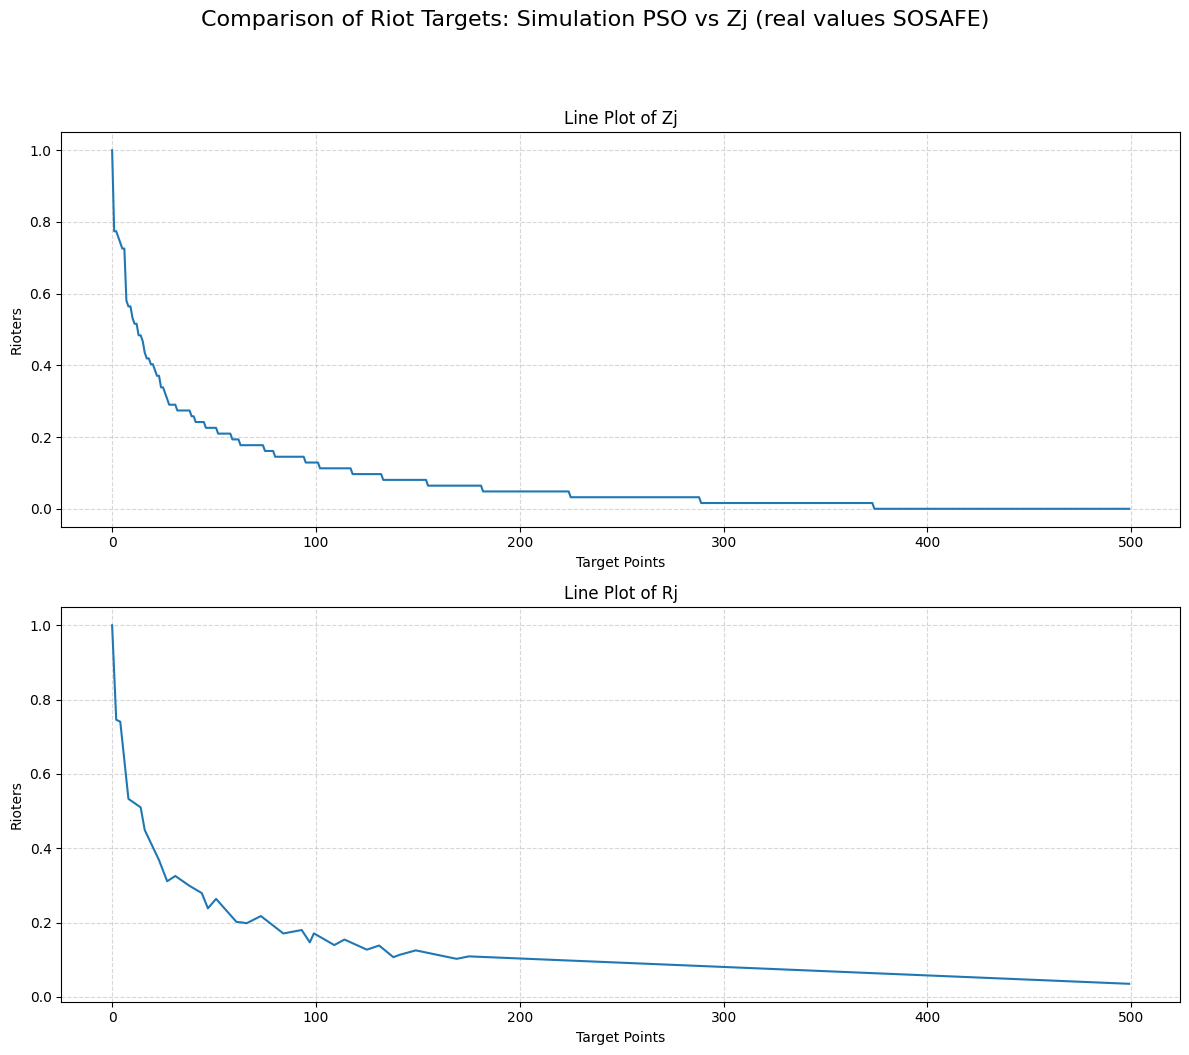

In [12]:
plot_results(Zj_scaled, Rj_simulated, "PSO")

In [13]:
def PSO(objective_function, max_iter, n, dim, w_range, c1, c2, bounds, device, tol=1e-6, patience=10):
    """
    Implementación de PSO en PyTorch con parada automática por convergencia.

    Args:
        (...otros argumentos...)
        tol (float): Tolerancia mínima de mejora para resetear la paciencia.
        patience (int): Número de iteraciones sin mejora para detener el algoritmo.
    """
    # Inicialización (sin cambios)
    min_bounds = bounds[:, 0]
    max_bounds = bounds[:, 1]
    positions = (max_bounds - min_bounds) * torch.rand(n, dim, device=device) + min_bounds
    velocities = torch.zeros(n, dim, device=device)

    personal_best_pos = positions.clone()
    personal_bests = torch.full((n, 1), float('inf'), device=device)

    fitnesses = objective_function(positions)
    personal_bests = torch.minimum(fitnesses, personal_bests)
    personal_best_pos = torch.where(fitnesses < personal_bests, positions, personal_best_pos) # Corregido orden

    global_best_val, best_idx = torch.min(personal_bests, dim=0)
    global_best_pos = personal_best_pos[best_idx[0]].clone()

    # <--- AÑADIDO: Variables para la parada automática ---
    patience_counter = 0
    last_best_val = global_best_val.item()
    # ----------------------------------------------------

    for curr_iter in range(max_iter):
        # ... (actualización de w, velocidades y posiciones sin cambios) ...
        w = w_range[0] - (w_range[0] - w_range[1]) * (curr_iter / max_iter)
        r1, r2 = torch.rand(2, n, dim, device=device)
        cognitive = c1 * r1 * (personal_best_pos - positions)
        social = c2 * r2 * (global_best_pos - positions)
        velocities = w * velocities + cognitive + social
        positions += velocities
        positions.clamp_(min=min_bounds, max=max_bounds)

        # ... (evaluación y actualización de mejores personales sin cambios) ...
        fitnesses = objective_function(positions)
        update_mask = (fitnesses < personal_bests).squeeze()
        personal_best_pos[update_mask] = positions[update_mask]
        personal_bests = torch.minimum(fitnesses, personal_bests)

        # ... (actualización del mejor global sin cambios) ...
        current_best_val, current_best_idx = torch.min(personal_bests, dim=0)
        if current_best_val < global_best_val:
            global_best_val = current_best_val
            global_best_pos = personal_best_pos[current_best_idx[0]].clone()

        print(f"PSO - Iteración: {curr_iter+1}/{max_iter}, Error: {global_best_val.item():.6f}")

        # <--- AÑADIDO: Lógica de parada automática ---
        # Comprobar si la mejora es menor que la tolerancia
        if (last_best_val - global_best_val.item()) < tol:
            patience_counter += 1
        else:
            # Si hay mejora, se resetea el contador
            patience_counter = 0

        # Actualizar el mejor valor de la iteración anterior
        last_best_val = global_best_val.item()

        # Si el contador de paciencia alcanza el límite, detenerse
        if patience_counter >= patience:
            print(f"\nConvergencia alcanzada en la iteración {curr_iter + 1}. La mejora fue menor que {tol} durante {patience} iteraciones.")
            break
        # -----------------------------------------------

    return global_best_val.item(), global_best_pos.tolist()

In [14]:
def objective_function(params, dij, Ii, Zj, target_results):
    """
    Objective function for optimization. Can accept a single set of parameters or a batch.
    Args:
        params (torch.Tensor): Tensor containing parameters on the target device.
                               Can be a single set [dim] or a batch [n, dim].
        dij, Ii, Zj, target_results: Additional fixed arguments for the simulation.
    Returns:
        torch.Tensor: Tensor containing the error for each set of parameters, on the same device as params.
    """
    # Get the correct device from the input tensor.
    device = params.device

    # Ensure the target results tensor is on the correct device.
    target_results_t = torch.from_numpy(target_results).float().to(device)

    # Make sure params is a 2D tensor for consistent iteration.
    if params.dim() == 1:
        params = params.unsqueeze(0)

    is_batch = (params.shape[0] > 1)
    errors = []

    # Iterate over the batch of parameter sets.
    for param_set in params:
        # Extract scalar values for the simulation function.
        beta_r, gamma_r, alpha_p, gamma_p = param_set.tolist()

        # The run_simulation function returns a NumPy array, which is on the CPU.
        simulation_results_np = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

        # Convert the NumPy result to a tensor and move it to the correct device.
        simulation_results_t = torch.from_numpy(simulation_results_np).float().to(device)

        # Calculate the error on the GPU.
        error = torch.linalg.norm(simulation_results_t - target_results_t)
        errors.append(error)

        # Print params and errors
        print(f"Params: {param_set}, Error: {error}")

    # Create the final error tensor directly on the target device.
    errors_t = torch.tensor(errors, device=device)

    # Return a tensor with the correct shape for the PSO algorithm.
    if not is_batch:
        it_error = errors_t.squeeze() # Return scalar for a single input
        print(f"Error: {it_error}")
        return it_error # Return scalar for a single input
    else:
        it_error = errors_t.unsqueeze(1) # Return column tensor for batch input
        print(f"Error: {it_error}")
        return it_error # Return column tensor for batch input

In [15]:
# Datos de entrada (ajustar según tu caso)
# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")
target_results = Zj_scaled

# Configuración del PSO

max_iter = 10
n_particles = 10
dim = 4  # Número de parámetros a optimizar (beta_r, gamma_r, alpha_p, gamma_p)
w = 0.5
c1 = 1.5
c2 = 1.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
init_min_x = torch.from_numpy(np.array([0.01, 0.15, 0.05, 0.01])).to(device)
init_max_x = torch.from_numpy(np.array([0.1, 0.25, 1.5, 0.05])).to(device)

# Función objetivo envuelta para pasar argumentos adicionales
def wrapped_objective_function(params):
    return objective_function(params, dij, Ii, Zj, target_results)

# PSO parameters
# beta_r = 0.1
# gamma_r = 0.19482765
# alpha_p = 0.97356374
# gamma_p = 0.03415131

In [16]:
# Ejecución del PSO
import time

start_time = time.time()

bounds = torch.stack([init_min_x, init_max_x], dim=1)
best_error, best_params = PSO(wrapped_objective_function, max_iter, n_particles, dim, (w, w), c1, c2, bounds, device)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Mejor error encontrado: {best_error}")
print(f"Mejores parámetros encontrados: {best_params}")
print(f"Tiempo empleado: {elapsed_time}")

Starting loop ...
Total execution time:  3.41971492767334
Params: tensor([0.0685, 0.1916, 1.1948, 0.0217], device='cuda:0', dtype=torch.float64), Error: 2.2331483364105225
Starting loop ...
Total execution time:  3.3399436473846436
Params: tensor([0.0334, 0.1895, 1.1405, 0.0319], device='cuda:0', dtype=torch.float64), Error: 1.1516762971878052
Starting loop ...
Total execution time:  3.310903787612915
Params: tensor([0.0719, 0.1620, 1.4429, 0.0136], device='cuda:0', dtype=torch.float64), Error: 4.241713047027588
Starting loop ...
Total execution time:  3.2866714000701904
Params: tensor([0.0722, 0.2248, 0.6774, 0.0422], device='cuda:0', dtype=torch.float64), Error: 1.0939778089523315
Starting loop ...
Total execution time:  3.3305001258850098
Params: tensor([0.0718, 0.1779, 1.2294, 0.0424], device='cuda:0', dtype=torch.float64), Error: 2.922025680541992
Starting loop ...
Total execution time:  3.3384461402893066
Params: tensor([0.0160, 0.1667, 0.2167, 0.0160], device='cuda:0', dtype=tor

In [17]:
print("""Mejor error encontrado: 0.8456938862800598""")
print("""Mejores parámetros encontrados: [0.05, 0.18981107922192167, 0.5499781710410232, 0.019925854043879795]""")
print("""Tiempo empleado: 372.54783034324646""")

Mejor error encontrado: 0.8456938862800598
Mejores parámetros encontrados: [0.05, 0.18981107922192167, 0.5499781710410232, 0.019925854043879795]
Tiempo empleado: 372.54783034324646


In [18]:
print(
"""
Mejor error encontrado: 0.8380632400512695
Mejores parámetros encontrados: [0.08080083881320638, 0.16212590273084806, 0.944998331859234, 0.012843916502695745]
Tiempo empleado: 369.49545669555664
"""
)


Mejor error encontrado: 0.8380632400512695
Mejores parámetros encontrados: [0.08080083881320638, 0.16212590273084806, 0.944998331859234, 0.012843916502695745]
Tiempo empleado: 369.49545669555664



In [24]:
print(
    """
    Mejor error encontrado: 0.8395642638206482
    Mejores parámetros encontrados: [0.07817706352657117, 0.17972824644326665, 1.0111028126699637, 0.02466220477202307]
    Tiempo empleado: 371.39731073379517

    """
    )


    Mejor error encontrado: 0.8395642638206482
    Mejores parámetros encontrados: [0.07817706352657117, 0.17972824644326665, 1.0111028126699637, 0.02466220477202307]
    Tiempo empleado: 371.39731073379517

    


In [19]:
beta_r, gamma_r, alpha_p, gamma_p = best_params

In [20]:
Rj_PSO_opt = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

Starting loop ...
Total execution time:  3.4452342987060547


In [21]:
print_detailed_comparison_sklearn(Rj_PSO_opt, target_results)

Métricas de error:
RMSE: 0.0375
MAE: 0.0333
R² Score: 0.9210
Error máximo: 0.1618


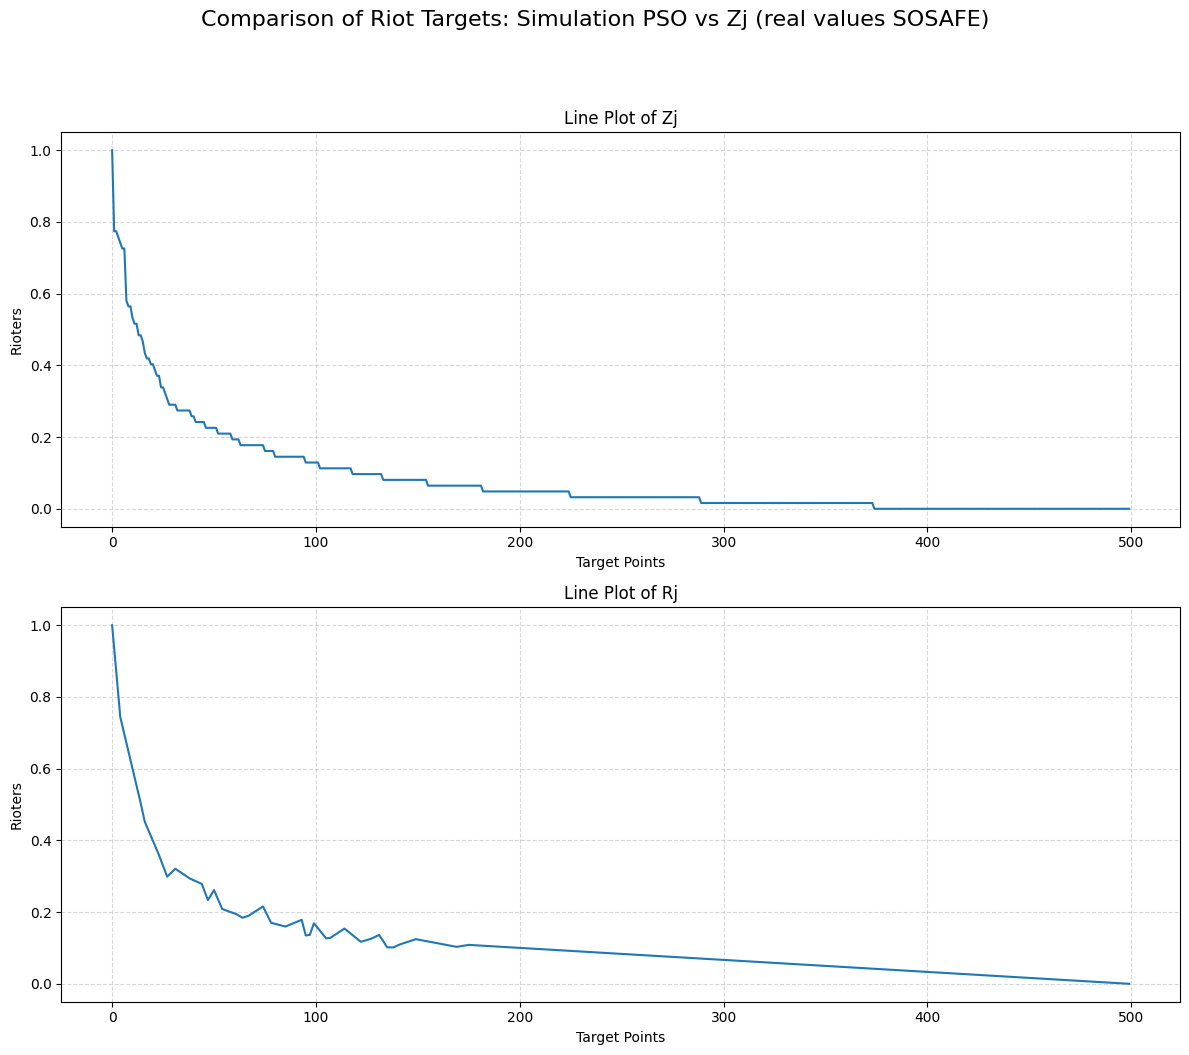

In [22]:
plot_results(target_results, Rj_PSO_opt, "PSO")